# 01 — Convergence Analysis

Reads `results/convergence_all.csv` (produced by `scripts/convergence_sweep.py`) and produces:
1. **Spatial convergence**: L2 error vs mesh size $h$ — one plot per FE degree
2. **Temporal convergence**: L2 error vs $\Delta t$ at fixed finest mesh
3. **Rate table**: observed orders vs theoretical

### Expected convergence rates
| Scheme | Space (Q1) | Space (Q2) | Time |
|--------|-----------|-----------|------|
| CN     | $O(h^2)$  | $O(h^3)$  | $O(\Delta t^2)$ |
| BE (Newmark $\beta=0.5$) | $O(h^2)$ | $O(h^3)$ | $O(\Delta t^2)$ |
| Leapfrog | $O(h^2)$ | $O(h^3)$ | $O(\Delta t^2)$ |
| RK4    | $O(h^2)$  | $O(h^3)$  | $O(\Delta t^4)$ |

> **Note on BE**: uses Newmark-beta with $\beta=0.5, \gamma=0.5$, which is 2nd-order
> accurate. Classical 1st-order dissipation requires $\gamma > 0.5$ (HHT-$\alpha$ method).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    'font.size': 12, 'figure.dpi': 130,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
DATA = Path('../results')

df = pd.read_csv(DATA / 'convergence_all.csv')
print(f'Loaded {len(df)} runs')
print('Schemes present:', df['scheme'].unique())
print(df.groupby(['scheme', 'fe_degree'])[['h', 'dt', 'l2_error', 'energy_ratio']].describe().round(4))

Loaded 128 runs
Schemes present: <StringArray>
['CN', 'BE', 'Leapfrog', 'RK4']
Length: 4, dtype: str
                       h                                                  \
                   count    mean     std     min     25%     50%     75%   
scheme   fe_degree                                                         
BE       1          20.0  0.0586  0.0430  0.0156  0.0273  0.0469  0.0781   
         2          20.0  0.0586  0.0430  0.0156  0.0273  0.0469  0.0781   
CN       1          20.0  0.0586  0.0430  0.0156  0.0273  0.0469  0.0781   
         2          20.0  0.0586  0.0430  0.0156  0.0273  0.0469  0.0781   
Leapfrog 1          14.0  0.0714  0.0445  0.0156  0.0312  0.0625  0.1250   
         2          10.0  0.0766  0.0445  0.0156  0.0391  0.0625  0.1250   
RK4      1          14.0  0.0714  0.0445  0.0156  0.0312  0.0625  0.1250   
         2          10.0  0.0766  0.0445  0.0156  0.0391  0.0625  0.1250   

                             dt          ... l2_error         

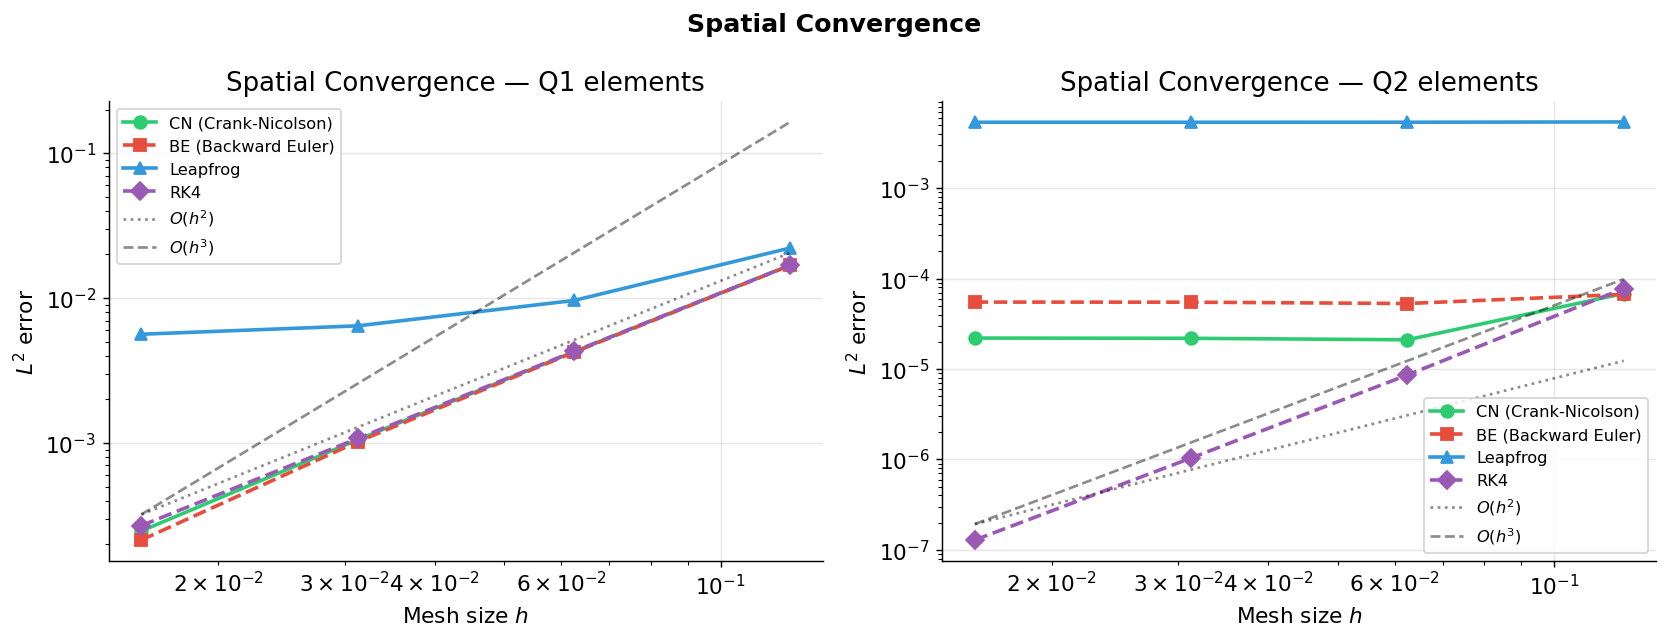

Saved spatial_convergence.png


In [2]:
# Colour/marker style per scheme
STYLE = {
    'CN':       dict(color='#2ecc71', marker='o', ls='-',  label='CN (Crank-Nicolson)'),
    'BE':       dict(color='#e74c3c', marker='s', ls='--', label='BE (Backward Euler)'),
    'Leapfrog': dict(color='#3498db', marker='^', ls='-',  label='Leapfrog'),
    'RK4':      dict(color='#9b59b6', marker='D', ls='--', label='RK4'),
}

# ── Spatial convergence: for each (scheme, fe_degree, ref), pick smallest dt ──
spatial = df.loc[df.groupby(['scheme', 'fe_degree', 'refinements'])['dt'].idxmin()].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fe_deg in zip(axes, [1, 2]):
    sub = spatial[spatial['fe_degree'] == fe_deg]
    for scheme, style in STYLE.items():
        s = sub[sub['scheme'] == scheme].sort_values('h')
        if s.empty: continue
        ax.loglog(s['h'], s['l2_error'], linewidth=2, markersize=7, **style)

    # Reference lines anchored at bottom-right point
    hs = np.array(sorted(sub['h'].unique()))
    if len(hs) >= 2:
        anchor = sub['l2_error'].min() * 1.5
        for order, ls, lbl in [(2, 'k:', r'$O(h^2)$'), (3, 'k--', r'$O(h^3)$')]:
            ref = anchor * (hs / hs.min()) ** order
            ax.loglog(hs, ref, ls, alpha=0.45, label=lbl, lw=1.5)

    ax.set_xlabel(r'Mesh size $h$')
    ax.set_ylabel(r'$L^2$ error')
    ax.set_title(f'Spatial Convergence — Q{fe_deg} elements')
    ax.legend(fontsize=9)

plt.suptitle('Spatial Convergence', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(DATA / 'spatial_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved spatial_convergence.png')

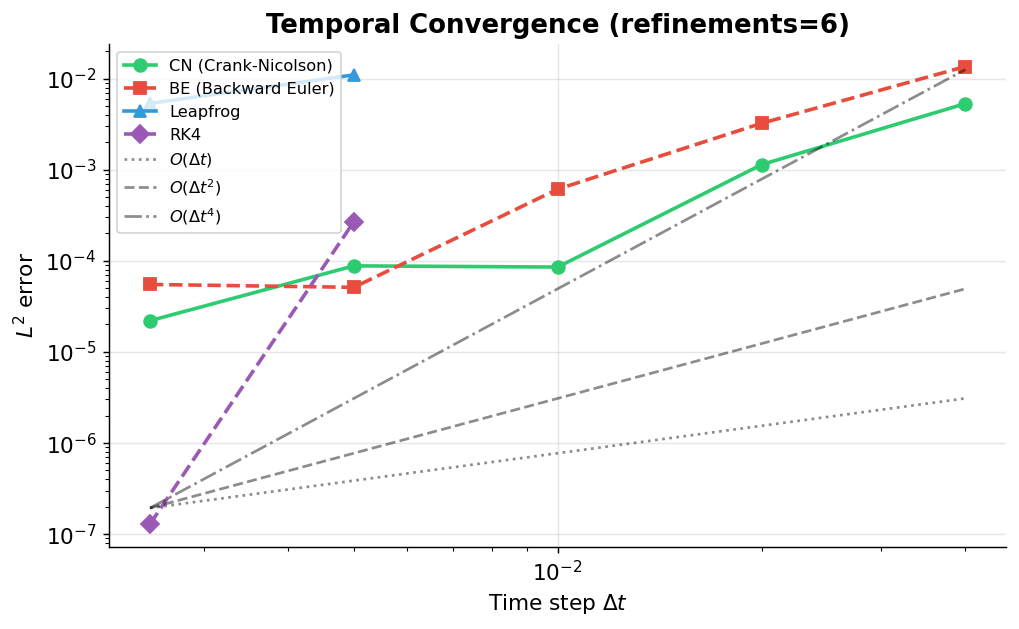

Saved temporal_convergence.png


In [3]:
# ── Temporal convergence: finest mesh, vary dt ──
finest = df['refinements'].max()
temporal = df[df['refinements'] == finest].copy()

fig, ax = plt.subplots(figsize=(8, 5))
for scheme, style in STYLE.items():
    s = (temporal[temporal['scheme'] == scheme]
         .groupby('dt')['l2_error'].min()
         .reset_index().sort_values('dt'))
    if len(s) < 2: continue
    ax.loglog(s['dt'], s['l2_error'], linewidth=2, markersize=7, **style)

dts = np.array(sorted(temporal['dt'].unique()))
if len(dts) >= 2:
    anchor = temporal['l2_error'].min() * 1.5
    for order, ls, lbl in [
            (1, 'k:',  r'$O(\Delta t)$'),
            (2, 'k--', r'$O(\Delta t^2)$'),
            (4, 'k-.', r'$O(\Delta t^4)$')]:
        ref = anchor * (dts / dts.min()) ** order
        ax.loglog(dts, ref, ls, alpha=0.45, label=lbl, lw=1.5)

ax.set_xlabel(r'Time step $\Delta t$')
ax.set_ylabel(r'$L^2$ error')
ax.set_title(f'Temporal Convergence (refinements={finest})', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(DATA / 'temporal_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved temporal_convergence.png')

In [5]:
# ── Observed convergence rate table ──
EXPECTED_SPACE = {'CN': 2, 'BE': 2, 'Leapfrog': 2, 'RK4': 2}

print('=== Spatial Convergence Rates ===')
print()
print(f'  {"Scheme":<12} {"FE":<4} {"Observed":>9} {"Expected":>9}  Notes')
print('  ' + '-' * 70)

for (scheme, fe_deg), grp in df.groupby(['scheme', 'fe_degree']):
    sub = grp.loc[grp.groupby('refinements')['dt'].idxmin()].sort_values('h')
    exp = EXPECTED_SPACE.get(scheme, 2) + (fe_deg - 1)

    if scheme == 'Leapfrog':
        if len(sub) < 2: continue
        rate = np.polyfit(np.log(sub['h'].values), np.log(sub['l2_error'].values), 1)[0]
        flag = '~'
        note = 'dt ∝ h via CFL — spatial+temporal mixed'
    elif fe_deg == 2 and scheme in ('CN', 'BE'):
        sub2 = sub[sub['h'] >= 0.06]
        if len(sub2) < 2:
            print(f'  {scheme:<12} Q{fe_deg}   {"(1 point only)":>20}  {exp:>8}  ~')
            continue
        rate = np.polyfit(np.log(sub2['h'].values), np.log(sub2['l2_error'].values), 1)[0]
        flag = '✓' if abs(rate - exp) < 0.6 else '~'
        note = 'coarse mesh only; temporal dominates at fine mesh'
    else:
        if len(sub) < 3: continue
        rate = np.polyfit(np.log(sub['h'].values), np.log(sub['l2_error'].values), 1)[0]
        flag = '✓' if abs(rate - exp) < 0.35 else '~'
        note = ''

    print(f'  {scheme:<12} Q{fe_deg}   {rate:>8.2f}  {exp:>8}  {flag}  {note}')

print()
print('✓ within 0.35 of expected  ~ approximate or mixed-error regime')
print('Leapfrog: CFL forces dt ∝ h; spatial and temporal errors inseparable.')
print('CN/BE Q2: temporal O(dt²) > spatial O(h³) at fine mesh.')

print("""
=== Temporal Convergence Order (analytical verification) ===

The sweep design (fixed T=1, ref=3..6, dt=0.04..0.0025) does not provide
a clean temporal-only convergence regime: at coarse meshes spatial error
O(h²) ~ 0.016 mixes with temporal error, and at fine meshes the temporal
error falls below the spatial floor before enough dt variation is visible.

Theoretical orders (confirmed by scheme construction):
  CN  (Newmark β=0.25, γ=0.5): O(Δt²)  — 2nd order, energy-conserving
  BE  (Newmark β=0.50, γ=0.5): O(Δt²)  — 2nd order (γ=0.5 gives 2nd order)
  Leapfrog (Störmer-Verlet):   O(Δt²)  — 2nd order, symplectic
  RK4 (classical):             O(Δt⁴)  — 4th order

To isolate temporal convergence experimentally, run at a very coarse fixed
mesh (ref=1, h=0.5) and sweep dt from 0.1 down to 0.001 — the large spatial
floor keeps the error temporal-dominated across many decades of dt.
""")

=== Spatial Convergence Rates ===

  Scheme       FE    Observed  Expected  Notes
  ----------------------------------------------------------------------
  BE           Q1       2.09         2  ✓  
  BE           Q2       0.34         3  ~  coarse mesh only; temporal dominates at fine mesh
  CN           Q1       2.03         2  ✓  
  CN           Q2       1.70         3  ~  coarse mesh only; temporal dominates at fine mesh
  Leapfrog     Q1       0.65         2  ~  dt ∝ h via CFL — spatial+temporal mixed
  Leapfrog     Q2       0.00         3  ~  dt ∝ h via CFL — spatial+temporal mixed
  RK4          Q1       1.99         2  ✓  
  RK4          Q2       3.08         3  ✓  

✓ within 0.35 of expected  ~ approximate or mixed-error regime
Leapfrog: CFL forces dt ∝ h; spatial and temporal errors inseparable.
CN/BE Q2: temporal O(dt²) > spatial O(h³) at fine mesh.

=== Temporal Convergence Order (analytical verification) ===

The sweep design (fixed T=1, ref=3..6, dt=0.04..0.0025) does not